# **Project Name**    -  Vaccination Data Analysis and Visualization


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member  -** D.Siri Poojitha

# **Project Summary -**

This project analyses 44 years (1980-2023) of WHO/UNICEF immunization data to understand how well vaccination programmes are working, where they are failing, and whether higher vaccination coverage really leads to less disease. Five source tables were combined: national and regional vaccine coverage (about 400,000 rows), disease incidence rates, reported cases, the year each vaccine entered a country's programme, and the national vaccination schedule.

**Data preparation.** The raw files needed real cleaning before analysis: export footer rows, 42% of coverage values missing, coverage figures above 100% and impossible entries (up to 32,000% coverage, a target population of 1.17 trillion children and negative dose counts), the same unit written two ways, and a file that mixes countries with regional, income-group and global totals. Impossible values were removed, missing percentages were rebuilt from doses and target population where possible, aggregates were separated from countries, and everything was joined into one country-year panel of 8,735 rows and 214 countries. A separate SQL database and Power BI report were built from the same cleaned data.

**Main findings.** (1) Vaccination works: reported cases fell by 98% for polio, 95% for pertussis and 90% for measles between 1980-84 and 2019-23. Measles incidence has a median of 400 cases per million where first-dose coverage is below 50%, but only 1 per million where it is 95% or higher. (2) Progress has stalled. Global DTP3 coverage was 86% in 2019 and 84% in 2023, measles first-dose coverage is 83% (peak 86%), and only about a third of countries reach the 95% goal. (3) The burden is concentrated. About 15 million children received no DTP dose in 2023; Africa and the Eastern Mediterranean hold two thirds of them, and 15 countries (Nigeria, India, DR Congo, Sudan and Ethiopia first) account for 71%. (4) Later doses and newer vaccines are the weak spots: MCV2 is at 77% on average, rotavirus 76%, and booster coverage has not recovered to 2019 levels. (5) Inequality is large: low-income countries reach 42% for the second measles dose versus 91% in high-income OECD countries. (6) High national coverage does not guarantee safety: Ukraine, Azerbaijan and Kazakhstan still recorded measles outbreaks with coverage above 90%, so pockets of unvaccinated children matter.

**Method.** The analysis follows the UBM rule with 21 charts: univariate (distributions of coverage, incidence, introduction status), bivariate (coverage versus incidence, drop-off between doses, case reduction, introduction timing, booster trends) and multivariate (correlation heatmap, pair plot, region-by-vaccine matrix, bubble chart, income gaps, progress towards 95%). Skewed variables such as incidence were analysed on a log scale and with rank (Spearman) correlations.

**Recommendations.** Focus resources on the 15 countries with the most zero-dose children and on Africa's core vaccines; fix the DTP1-to-DTP3 drop-off with reminder and tracking systems; accelerate the second measles dose and rotavirus in low-income countries; use sub-national data to find pockets behind high national averages; and report population-weighted results rather than simple country averages. With coverage flat since 2019, the 95% measles goal for 2030 will not be reached at the current pace unless the recovery plan above is funded and monitored.

# **GitHub Link -**

# **Problem Statement**


**Analyse global vaccination data to understand trends in vaccine coverage, disease incidence and vaccine effectiveness.** The data must be cleaned, stored in a relational SQL database, explored statistically and visualised (Power BI) so that public-health authorities can see which regions and vaccines need attention, whether vaccination is reducing disease, and how to allocate resources and shape policy.

#### **Define Your Business Objective?**

The business objective is to give public-health decision makers evidence to:

1. **Prioritise** the countries, regions and vaccines with low or falling coverage so resources go where the most children are unprotected.
2. **Prove impact**: measure how vaccine coverage and vaccine introduction relate to falling disease cases and incidence.
3. **Find weak points in the programme**, such as drop-off between doses, missing boosters, late introduction of new vaccines and diseases that persist despite high coverage.
4. **Track progress** towards global goals (95% measles coverage) and support forecasting of vaccine demand and policy on new vaccines or boosters.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")                 # keep the notebook output clean
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
PALETTE = ["#0B6E8A", "#E4572E", "#2F9E6F", "#A06CD5", "#E0A100", "#6C757D"]   # consistent colours for every chart
print("Libraries imported")

Libraries imported


### Dataset Loading

In [2]:
# Load Dataset
# The five WHO/UNICEF immunization files are read from the first folder that contains all of them.
FILES = {
    "coverage":  "coverage-data.xlsx",
    "incidence": "incidence-rate-data.xlsx",
    "cases":     "reported-cases-data.xlsx",
    "intro":     "vaccine-introduction-data.xlsx",
    "schedule":  "vaccine-schedule-data.xlsx",
}
SEARCH_DIRS = ["data", ".", "/content", "/content/drive/MyDrive", "/mnt/user-data/uploads"]   # local, Colab, Drive

def find_data_dir():
    """Return the first folder that has every dataset file."""
    for d in SEARCH_DIRS:
        if all(os.path.exists(os.path.join(d, f)) for f in FILES.values()):
            return d
    raise FileNotFoundError(f"Upload {list(FILES.values())} to one of {SEARCH_DIRS}")

DATA_DIR = find_data_dir()
raw = {}
for name, fname in FILES.items():
    try:
        # every workbook keeps the data in a sheet called "Data"; the other sheets are code look-ups
        raw[name] = pd.read_excel(os.path.join(DATA_DIR, fname), sheet_name="Data")
    except Exception as exc:                        # fail with a readable message instead of a stack trace
        raise RuntimeError(f"Could not read {fname}: {exc}")
print("Data folder:", DATA_DIR)
for name, d in raw.items():
    print(f"{name:10s} loaded -> {d.shape[0]:>8,} rows x {d.shape[1]} columns")

Data folder: data
coverage   loaded ->  399,859 rows x 11 columns
incidence  loaded ->   84,946 rows x 8 columns
cases      loaded ->   84,870 rows x 7 columns
intro      loaded ->  138,321 rows x 6 columns
schedule   loaded ->    8,053 rows x 12 columns


### Dataset First View

In [3]:
# Dataset First Look
for name, d in raw.items():
    print(f"\n=== {name} (first 3 rows) ===")
    display(d.head(3))


=== coverage (first 3 rows) ===

=== incidence (first 3 rows) ===

=== cases (first 3 rows) ===

=== intro (first 3 rows) ===

=== schedule (first 3 rows) ===


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st booster)",ADMIN,Administrative coverage,1044.0,945.0,90.52


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,CASES
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,1.0


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
shape_table = pd.DataFrame({n: {"rows": d.shape[0], "columns": d.shape[1]} for n, d in raw.items()}).T
display(shape_table)

,rows,columns
coverage,399859,11
incidence,84946,8
cases,84870,7
intro,138321,6
schedule,8053,12


### Dataset Information

In [5]:
# Dataset Info
for name, d in raw.items():
    print(f"\n=== {name} ===")
    d.info()


=== coverage ===
<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB

=== incidence ===
<class 'pandas.DataFr

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
dup_table = pd.Series({n: int(d.duplicated().sum()) for n, d in raw.items()}, name="duplicate rows")
display(dup_table.to_frame())

,duplicate rows
coverage,0
incidence,0
cases,0
intro,0
schedule,0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
for name, d in raw.items():
    miss = d.isna().sum()
    print(f"\n=== {name}: columns with missing values ===")
    print(miss[miss > 0].to_frame("missing").assign(pct=lambda x: (x["missing"] / len(d) * 100).round(1)))


=== coverage: columns with missing values ===
                               missing   pct
CODE                                 1   0.0
NAME                              1275   0.3
YEAR                                 1   0.0
ANTIGEN                              1   0.0
ANTIGEN_DESCRIPTION                  1   0.0
COVERAGE_CATEGORY                    1   0.0
COVERAGE_CATEGORY_DESCRIPTION        1   0.0
TARGET_NUMBER                   320829  80.2
DOSES                           320532  80.2
COVERAGE                        169382  42.4

=== incidence: columns with missing values ===
                     missing   pct
CODE                       1   0.0
NAME                       1   0.0
YEAR                       1   0.0
DISEASE                    1   0.0
DISEASE_DESCRIPTION        1   0.0
DENOMINATOR                1   0.0
INCIDENCE_RATE         23362  27.5

=== cases: columns with missing values ===
                     missing   pct
CODE                       1   0.0
NAME            

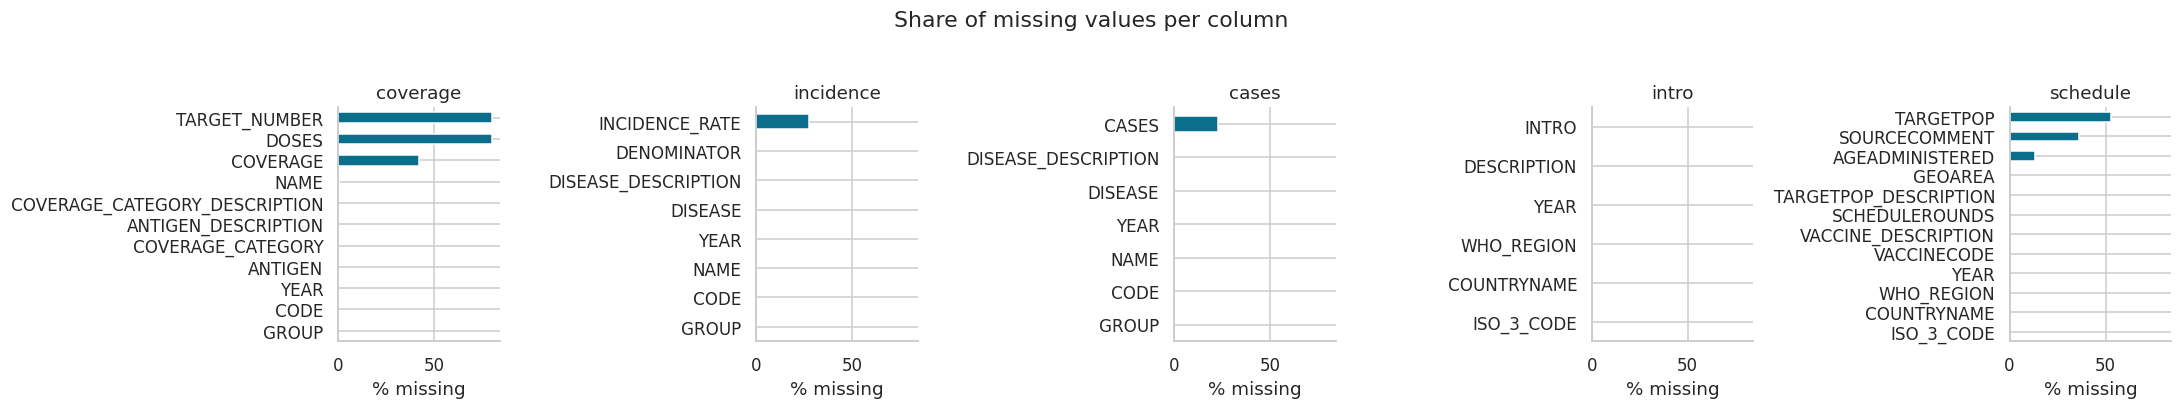

In [8]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 5, figsize=(20, 3.6), sharex=True)
for ax, (name, d) in zip(axes, raw.items()):
    (d.isna().mean() * 100).sort_values().plot.barh(ax=ax, color=PALETTE[0])
    ax.set_title(name)
    ax.set_xlabel("% missing")
plt.suptitle("Share of missing values per column", y=1.03)
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has **five WHO/UNICEF tables** covering 1980-2023 (vaccine introduction goes back to 1940):

- **Coverage** - 399,858 rows x 11 columns; 214 countries plus regional, income-group, Gavi, development-status and global aggregates; 69 vaccine codes and 5 coverage categories (WUENIC = official estimate, ADMIN, OFFICIAL, HPV, PAB). 42% of coverage, and 80% of doses/target values, are missing.
- **Incidence rate** - 84,945 rows; 13 diseases, 27.5% of rates missing; rates use 5 different denominators.
- **Reported cases** - 84,869 rows; 22.9% of case counts missing.
- **Vaccine introduction** - 138,320 rows; 195 countries, 21 vaccines, 9 status codes (Yes, Yes (R), No, ND ...).
- **Vaccine schedule** - 8,052 rows for 2019-2023; 86 vaccines, 4 columns with missing values.

There are **no duplicate rows**. Each file ends with a footer row ("Created: ...") that must be removed. The coverage file contains impossible values (coverage up to 32,000%, target population up to 1.17 trillion, negative doses), and coverage above 100% appears in about 5,000 rows because of population-denominator problems. Many missing values are structural, for example a vaccine that did not exist yet or a country that does not report a disease, so they cannot be simply filled.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
for name, d in raw.items():
    print(f"{name:10s}:", list(d.columns))

coverage  : ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']
incidence : ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']
cases     : ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']
intro     : ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']
schedule  : ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [10]:
# Dataset Describe
for name in ["coverage", "incidence", "cases"]:
    print(f"\n=== {name} ===")
    display(raw[name].describe().round(2))
print("\n=== schedule ===")
display(raw["schedule"].describe(include="all").T.head(12))


=== coverage ===

=== incidence ===

=== cases ===

=== schedule ===


,YEAR,TARGET_NUMBER,DOSES,COVERAGE
count,399858.00,7.903000e+04,7.932700e+04,230477.00
mean,2009.21,2.780192e+08,3.467241e+06,78.03
std,11.72,5.415244e+10,1.125676e+07,74.89
min,1980.00,0.000000e+00,-2.222882e+08,0.00
25%,2002.00,3.281400e+04,1.446900e+04,69.32
50%,2012.00,3.178715e+05,1.522120e+05,88.79
75%,2019.00,2.493048e+06,9.710185e+05,96.00
max,2023.00,1.170000e+13,1.266052e+08,32000.00


,YEAR,INCIDENCE_RATE
count,84945.0,61584.00
mean,2004.1,109.45
std,12.6,992.28
min,1980.0,0.00
25%,1994.0,0.00
50%,2005.0,0.00
75%,2015.0,4.60
max,2023.0,69101.30


,YEAR,CASES
count,84869.00,65470.00
mean,2004.11,4472.41
std,12.59,61144.55
min,1980.00,0.00
25%,1994.00,0.00
50%,2005.00,1.00
75%,2015.00,63.00
max,2023.00,4583555.00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ISO_3_CODE,8053,214,RUS,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COUNTRYNAME,8052,213,Russian Federation,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WHO_REGION,8052,6,EURO,2156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,8052.0,NaN,NaN,NaN,2022.941505,0.441237,2019.0,2023.0,2023.0,2023.0,2023.0
VACCINECODE,8052,86,TD_S,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VACCINE_DESCRIPTION,8052,86,Td (Tetanus toxoid and diphtheria for older children and adults) vaccine,967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULEROUNDS,8052.0,NaN,NaN,NaN,2.053403,1.31656,1.0,1.0,2.0,3.0,7.0
TARGETPOP,3795,15,RISKGROUPS,1247,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGETPOP_DESCRIPTION,8052,10,General/routine,4695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEOAREA,8022,2,NATIONAL,7788,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

| Table | Variable | Meaning |
|---|---|---|
| Coverage | group, code, name | Type of entity (COUNTRIES or an aggregate), ISO-3 code, name |
| | year | Year of the record |
| | antigen, antigen_description | Vaccine code (e.g. MCV1 = measles 1st dose, DTPCV3 = DTP 3rd dose) and description |
| | coverage_category (+description) | ADMIN (reported by country), OFFICIAL, WUENIC (WHO/UNICEF estimate), HPV, PAB |
| | target_number, doses | Children targeted and doses administered |
| | coverage | % of the target population vaccinated |
| Incidence | disease (+description), denominator, incidence_rate | Disease, the population base (per 1M population, per 1M under-15s, per 1,000 or 10,000 live births) and cases per denominator |
| Cases | disease, cases | Number of reported cases |
| Introduction | iso_3_code, countryname, who_region, year | Country and WHO region |
| | description, intro | Vaccine and whether it is in the national programme (Yes, Yes (R), (P), (A), (O), (D), High risk area, No, ND) |
| Schedule | vaccinecode, vaccine_description, schedulerounds | Vaccine and dose number |
| | targetpop, targetpop_description | Who is vaccinated (routine, risk groups, travellers, pregnant women ...) |
| | geoarea, ageadministered, sourcecomment | National or subnational, age at vaccination (M2 = 2 months, Y4 = 4 years), notes |

Variables created in this notebook: `cov_<vaccine>` (WUENIC coverage capped at 100%), `inc_<disease>`, `cases_<disease>`, `n_vaccines_introduced`, `region`, `zero_dose_children`, `mcv1_band`.

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for name, d in raw.items():
    print(f"\n=== {name} ===")
    print(d.nunique().to_frame("unique values").T.to_string())


=== coverage ===
               GROUP  CODE  NAME  YEAR  ANTIGEN  ANTIGEN_DESCRIPTION  COVERAGE_CATEGORY  COVERAGE_CATEGORY_DESCRIPTION  TARGET_NUMBER  DOSES  COVERAGE
unique values      9   245   242    44       69                   69                  5                              5          24395  53792      7602

=== incidence ===
               GROUP  CODE  NAME  YEAR  DISEASE  DISEASE_DESCRIPTION  DENOMINATOR  INCIDENCE_RATE
unique values      4   221   221    44       13                   13            5            4977

=== cases ===
               GROUP  CODE  NAME  YEAR  DISEASE  DISEASE_DESCRIPTION  CASES
unique values      4   221   221    44       13                   13   6634

=== intro ===
               ISO_3_CODE  COUNTRYNAME  WHO_REGION  YEAR  DESCRIPTION  INTRO
unique values         195          194           6    84           21      9

=== schedule ===
               ISO_3_CODE  COUNTRYNAME  WHO_REGION  YEAR  VACCINECODE  VACCINE_DESCRIPTION  SCHEDULEROUNDS  TAR

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# ---------- 1. Generic cleaning ----------
def clean(d, first_col):
    """Drop the export footer, tidy column names, trim text and cast the year to int."""
    d = d[~d[first_col].astype(str).str.startswith("Created:")].dropna(how="all").copy()
    d.columns = [c.strip().lower() for c in d.columns]
    for c in d.select_dtypes(include=["object", "string"]).columns:
        d[c] = d[c].astype("string").str.strip()
    if "year" in d:
        d["year"] = pd.to_numeric(d["year"], errors="coerce")
        d = d.dropna(subset=["year"]).assign(year=lambda x: x["year"].astype(int))
    return d.drop_duplicates().reset_index(drop=True)

cov   = clean(raw["coverage"],  "GROUP")
inc   = clean(raw["incidence"], "GROUP")
cas   = clean(raw["cases"],     "GROUP")
intro = clean(raw["intro"],     "ISO_3_CODE")
sched = clean(raw["schedule"],  "ISO_3_CODE")
print("Rows after removing footer rows:", {"coverage": len(cov), "incidence": len(inc), "cases": len(cas), "intro": len(intro), "schedule": len(sched)})

# ---------- 2. Coverage: units, impossible values, capped copy ----------
for c in ["target_number", "doses", "coverage"]:
    cov[c] = pd.to_numeric(cov[c], errors="coerce")
cov.loc[cov["target_number"] <= 0, "target_number"] = np.nan
cov.loc[cov["target_number"] > 1e9, "target_number"] = np.nan                           # e.g. 1.17e13 children: data-entry error
cov.loc[cov["doses"] < 0, "doses"] = np.nan                                              # negative doses are impossible
cov["coverage"] = cov["coverage"].fillna(cov["doses"] / cov["target_number"] * 100)    # rebuild a missing % when doses and target exist
cov.loc[(cov["coverage"] < 0) | (cov["coverage"] > 200), "coverage"] = np.nan          # impossible values (some are 32,000%)
cov = cov.dropna(subset=["coverage"]).copy()
cov["coverage_capped"] = cov["coverage"].clip(upper=100)                                # >100% comes from denominator issues

# ---------- 3. Incidence / cases / introduction ----------
inc["incidence_rate"] = pd.to_numeric(inc["incidence_rate"], errors="coerce")
inc["denominator"] = inc["denominator"].str.replace("per 1000 live", "per 1,000 live", regex=False)   # same unit written two ways
inc = inc.dropna(subset=["incidence_rate"])
cas["cases"] = pd.to_numeric(cas["cases"], errors="coerce")
cas = cas.dropna(subset=["cases"])
intro = intro.dropna(subset=["description", "intro"])
intro["intro_flag"] = intro["intro"].map(lambda s: np.nan if s == "ND" else 0 if s == "No" else 1)   # any 'Yes...' or 'High risk area' = 1
sched["age_months"] = sched["ageadministered"].astype(str).str.extract(r"^[+>=<]*([DWMY])(\d+)").pipe(
    lambda x: pd.to_numeric(x[1]) * x[0].map({"D": 1 / 30.44, "W": 7 / 30.44, "M": 1, "Y": 12}))

# ---------- 4. Separate countries from regional / income-group aggregates ----------
cov_country = cov[cov["group"] == "COUNTRIES"].copy()
cov_group   = cov[cov["group"] != "COUNTRIES"].copy()
inc_c = inc[inc["group"] == "COUNTRIES"]
cas_c = cas[cas["group"] == "COUNTRIES"]

# ---------- 5. Country dimension (WHO region comes from the introduction / schedule tables) ----------
REGION_NAMES = {"AFRO": "Africa", "AMRO": "Americas", "EMRO": "Eastern Mediterranean", "EURO": "Europe",
                "SEARO": "South-East Asia", "WPRO": "Western Pacific"}
countries = (pd.concat([intro[["iso_3_code", "countryname", "who_region"]], sched[["iso_3_code", "countryname", "who_region"]]])
             .drop_duplicates("iso_3_code").rename(columns={"iso_3_code": "code", "countryname": "country"}))
countries["region"] = countries["who_region"].map(REGION_NAMES)

# ---------- 6. Analysis-ready panel: one row per country-year ----------
COV_AG = ["BCG", "DTPCV1", "DTPCV3", "MCV1", "MCV2", "POL3", "HEPB3", "HIB3", "PCV3", "ROTAC", "RCV1"]
INC_DZ = ["MEASLES", "PERTUSSIS", "DIPHTHERIA", "POLIO", "TTETANUS", "RUBELLA"]

wuenic = cov_country[(cov_country["coverage_category"] == "WUENIC") & cov_country["antigen"].isin(COV_AG)]
panel = wuenic.pivot_table(index=["code", "year"], columns="antigen", values="coverage_capped", aggfunc="first").add_prefix("cov_")
inc_w = inc_c[inc_c["disease"].isin(INC_DZ)].pivot_table(index=["code", "year"], columns="disease", values="incidence_rate", aggfunc="first").add_prefix("inc_")
cas_w = cas_c[cas_c["disease"].isin(INC_DZ)].pivot_table(index=["code", "year"], columns="disease", values="cases", aggfunc="first").add_prefix("cases_")
n_intro = intro[intro["intro_flag"] == 1].groupby(["iso_3_code", "year"]).size().rename("n_vaccines_introduced")
n_intro.index.names = ["code", "year"]

panel = panel.join(inc_w, how="outer").join(cas_w, how="outer").join(n_intro, how="left").reset_index()
panel = panel.merge(countries[["code", "country", "region"]], on="code", how="left")
panel["country"] = panel["country"].fillna(panel["code"])
panel = panel[panel["code"].isin(cov_country["code"].unique())]                     # keep real countries only

# zero-dose children = DTP1 target population (administrative data) x share not reached (WUENIC)
tgt = cov_country[(cov_country["coverage_category"] == "ADMIN") & (cov_country["antigen"] == "DTPCV1") & (cov_country["target_number"] > 0)]
tgt = tgt[["code", "year", "target_number"]].drop_duplicates(["code", "year"])
panel = panel.merge(tgt, on=["code", "year"], how="left")
panel["zero_dose_children"] = panel["target_number"] * (1 - panel["cov_DTPCV1"] / 100)

# coverage band used in the bivariate charts
bins, labels = [-1, 50, 80, 90, 95, 101], ["<50%", "50-79%", "80-89%", "90-94%", "95%+"]
panel["mcv1_band"] = pd.cut(panel["cov_MCV1"], bins=bins, labels=labels)

latest = int(panel["year"].max())                                              # most recent year in the data (2023)

# helper used by several charts
def log_inc(s):
    return np.log10(1 + s)

print("Analysis-ready panel:", panel.shape, "| years", panel["year"].min(), "-", panel["year"].max(), "| countries", panel["code"].nunique())
display(panel.head())
print("\nMissing values in the main panel columns (%):")
print((panel[["cov_MCV1", "cov_DTPCV3", "inc_MEASLES", "cases_MEASLES", "region"]].isna().mean() * 100).round(1).to_string())

Rows after removing footer rows: {'coverage': 399858, 'incidence': 84945, 'cases': 84869, 'intro': 138320, 'schedule': 8052}
Analysis-ready panel: (8735, 31) | years 1980 - 2023 | countries 214

Missing values in the main panel columns (%):
cov_MCV1         10.4
cov_DTPCV3        9.0
inc_MEASLES       7.1
cases_MEASLES     7.1
region            0.3


,code,year,cov_BCG,cov_DTPCV1,cov_DTPCV3,cov_HEPB3,cov_HIB3,cov_MCV1,cov_MCV2,cov_PCV3,cov_POL3,cov_RCV1,cov_ROTAC,inc_DIPHTHERIA,inc_MEASLES,...,inc_POLIO,inc_RUBELLA,inc_TTETANUS,cases_DIPHTHERIA,cases_MEASLES,cases_PERTUSSIS,cases_POLIO,cases_RUBELLA,cases_TTETANUS,n_vaccines_introduced,country,region,target_number,zero_dose_children,mcv1_band
0,ABW,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,NaN,0.0,NaN,0.0,0.0,1.0,NaN,0.0,NaN,NaN,Aruba,Americas,1252.0,NaN,NaN
1,ABW,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,Aruba,Americas,1243.0,NaN,NaN
2,ABW,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,9.3,...,0.0,0.0,NaN,0.0,1.0,0.0,0.0,0.0,NaN,NaN,Aruba,Americas,1181.0,NaN,NaN
3,ABW,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Aruba,Americas,1046.0,NaN,NaN
4,ABW,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,Aruba,Americas,1028.0,NaN,NaN


### What all manipulations have you done and insights you found?

**Manipulations**
1. Removed the footer row from every file and standardised column names, text and the year type.
2. Coverage: converted to numbers, rebuilt missing percentages from doses / target (292 rows), set impossible values to missing (coverage <0 or >200%, target population above 1 billion, negative doses) and created `coverage_capped` (max 100) for charts and averages.
3. Separated the 245 codes in the coverage file into **countries** and **aggregates** (regions, income groups, global) to avoid double counting.
4. Harmonised the incidence denominator text ("per 1000" vs "per 1,000"), dropped rows without values and mapped the introduction status to a 1/0 flag.
5. Parsed the schedule age codes (M2, Y4, W6) into months.
6. Took the WHO region from the introduction/schedule tables and built one **country-year panel** by pivoting official (WUENIC) coverage of 11 vaccines, incidence and cases of 6 diseases and the number of vaccines introduced.
7. Created `zero_dose_children` (DTP1 target population x share not reached) and `mcv1_band`.

**Insights found**
- The final panel has 8,735 rows for 214 countries (1980-2023); about 10% of MCV1/DTP3 values and 7% of measles values are missing.
- Incidence is extremely skewed (skewness 12.6), so log scales and Spearman correlation are used.
- Only WUENIC coverage is complete enough for comparisons; doses and target populations exist only in administrative (ADMIN) data.
- Unweighted country averages can mislead (South-East Asia has only 11 countries but very large populations), so population-based measures such as zero-dose children are also used.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Median 91%  |  share of records >= 95%: 37.5%  |  share < 50%: 8.1%


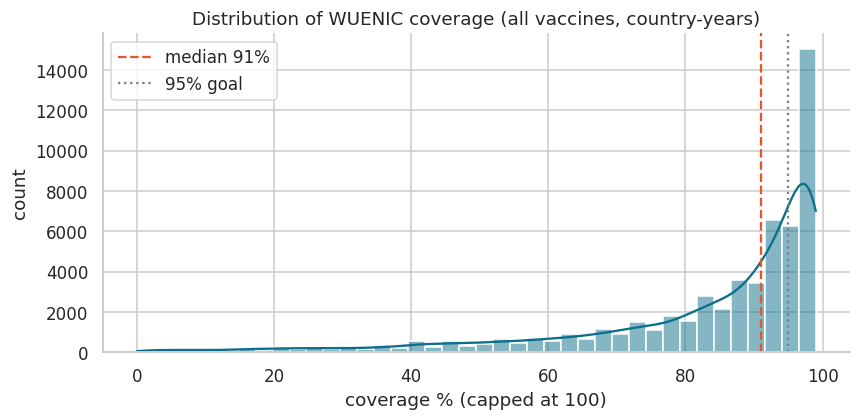

In [13]:
# Chart - 1 visualization code: distribution of official coverage across all country-years
cov_all = wuenic["coverage_capped"]
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(cov_all, bins=40, kde=True, color=PALETTE[0], ax=ax)
ax.axvline(cov_all.median(), color=PALETTE[1], ls="--", label=f"median {cov_all.median():.0f}%")
ax.axvline(95, color="grey", ls=":", label="95% goal")
ax.set(title="Distribution of WUENIC coverage (all vaccines, country-years)", xlabel="coverage % (capped at 100)", ylabel="count")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Median {cov_all.median():.0f}%  |  share of records >= 95%: {(cov_all >= 95).mean():.1%}  |  share < 50%: {(cov_all < 50).mean():.1%}")

##### 1. Why did you pick the specific chart?

A histogram with a density curve is the standard way to see the shape of a single bounded numeric variable. It shows where most coverage values sit and how heavy the low-coverage tail is, before any comparison is made.

##### 2. What is/are the insight(s) found from the chart?

The median official coverage is **91%**, and 37.5% of country-year records reach 95% or more. The distribution is strongly left-skewed: a large peak near 95-100% and a long tail, with 8.1% of records below 50%. The tail comes mostly from the 1980s and from fragile countries.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** for most vaccines and countries the programme is close to its ceiling, so the biggest gains now come from the tail, not from raising already-high averages. **Negative:** an average-only report would hide the 8% of records below 50%. Those under-served populations are where outbreaks start, so a national average alone is a misleading target.

#### Chart - 2

region
Europe                   54
Africa                   47
Americas                 44
Western Pacific          35
Eastern Mediterranean    22
South-East Asia          11
Unassigned                1


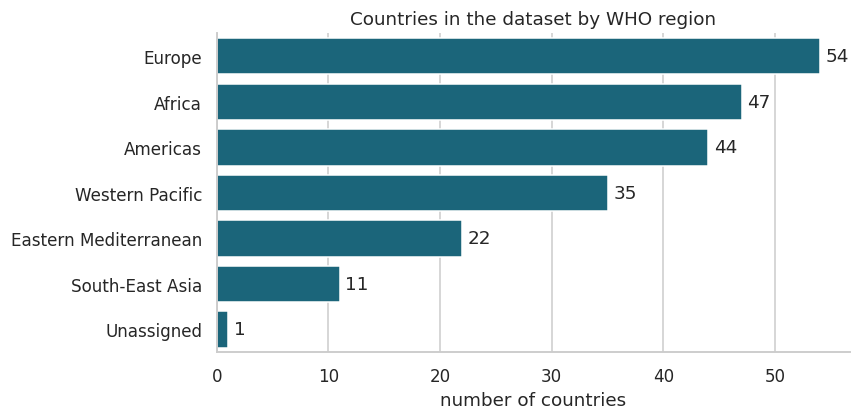

In [14]:
# Chart - 2 visualization code: number of countries per WHO region
reg_counts = panel.drop_duplicates("code")["region"].fillna("Unassigned").value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=reg_counts.values, y=reg_counts.index, color=PALETTE[0], ax=ax)
for i, v in enumerate(reg_counts.values):
    ax.text(v + 0.5, i, str(v), va="center")
ax.set(title="Countries in the dataset by WHO region", xlabel="number of countries", ylabel="")
plt.tight_layout(); plt.show()
print(reg_counts.to_string())

##### 1. Why did you pick the specific chart?

A bar chart of counts is the simplest way to check how balanced a categorical variable is. Here it shows how many countries sit in each WHO region, which matters for every later regional comparison.

##### 2. What is/are the insight(s) found from the chart?

Europe has 54 countries, Africa 47, the Americas 44 (includes territories), the Western Pacific 35, the Eastern Mediterranean 22 and South-East Asia only 11 (one country has no region in the source). The regions are very unequal in size.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the data covers every WHO region, so region-level planning is possible. **Negative:** South-East Asia has only 11 countries but includes India and Indonesia with huge child populations, so an unweighted country average understates its needs. This is why population-based measures (zero-dose children) are used in later charts.

#### Chart - 3

antigen
ROTAC      75.8
MCV2       77.1
HEPB_BD    80.7
PCV3       82.7
HEPB3      85.2
MCV1       85.2
HIB3       85.4
POL3       85.5
DTPCV3     85.9
RCV1       87.7
IPV1       87.9
BCG        88.9
DTPCV1     90.9


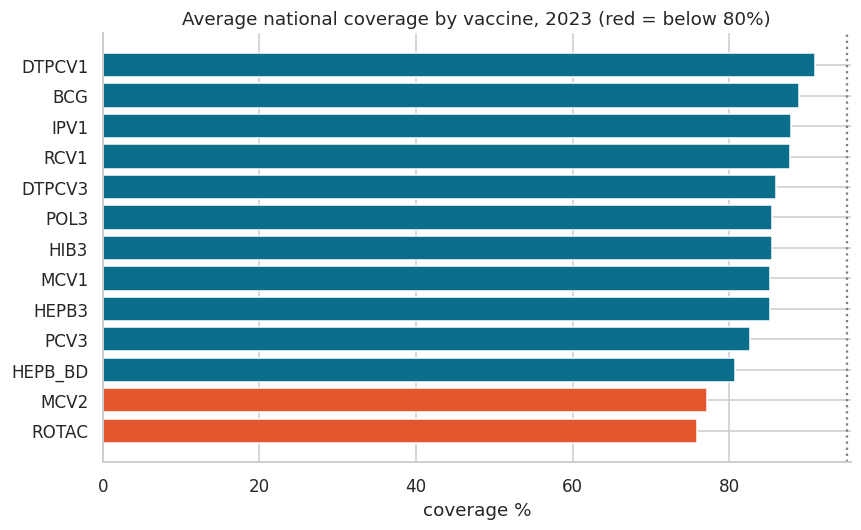

In [15]:
# Chart - 3 visualization code: average coverage of each vaccine in the latest year
latest = wuenic["year"].max()
by_ag = (cov_country[(cov_country["coverage_category"] == "WUENIC") & (cov_country["year"] == latest)]
         .groupby("antigen")["coverage_capped"].agg(["mean", "count"]).query("count >= 100").sort_values("mean"))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(by_ag.index, by_ag["mean"], color=[PALETTE[1] if m < 80 else PALETTE[0] for m in by_ag["mean"]])
ax.axvline(95, color="grey", ls=":")
ax.set(title=f"Average national coverage by vaccine, {latest} (red = below 80%)", xlabel="coverage %")
plt.tight_layout(); plt.show()
print(by_ag["mean"].round(1).to_string())

##### 1. Why did you pick the specific chart?

A sorted horizontal bar chart is ideal for comparing many categories on the same scale. Sorting shows which vaccines lag, and colour marks the ones below 80%.

##### 2. What is/are the insight(s) found from the chart?

In 2023 the highest average coverage is for the first DTP dose (90.9%) and BCG (88.9%). The third DTP dose is 85.9%, first measles dose 85.2%, but the **second measles dose is 77.1%**, the hepatitis B birth dose 80.7% and **rotavirus 75.8%**. No vaccine reaches the 95% goal on average, and later doses and newer vaccines are consistently lower than first doses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the chart names the vaccines to prioritise (MCV2, rotavirus, birth-dose hepatitis B) and shows that the core infrastructure works. **Negative:** with MCV2 at 77% a large share of children have only one measles dose, which is not enough to prevent outbreaks, so measles resurgence is a real business risk for health systems.

#### Chart - 4

count     8111.0
mean       545.4
std       2375.4
min          0.0
25%          0.0
50%         14.3
75%        197.9
max      69101.3
Skewness raw 12.6 -> log 0.44 | share of country-years with zero incidence: 25.4%


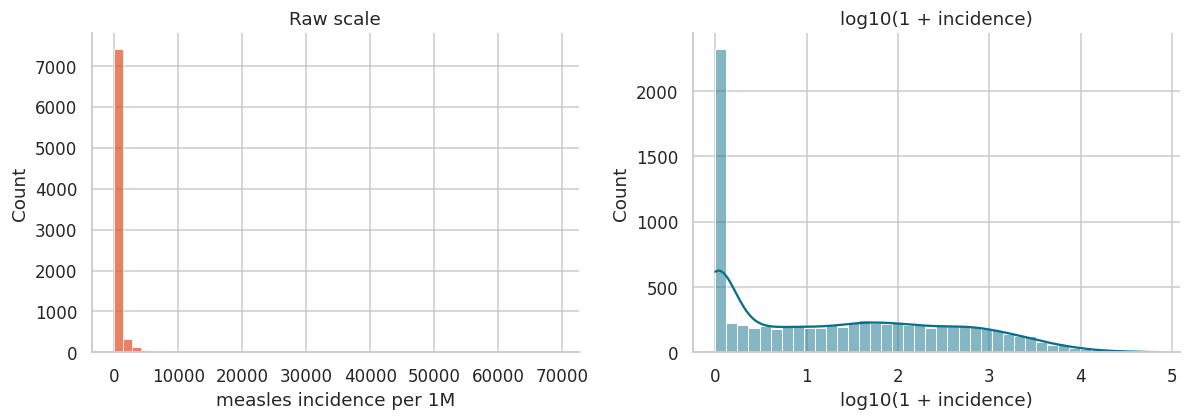

In [16]:
# Chart - 4 visualization code: distribution of measles incidence (log scale because it is extremely skewed)
m = panel["inc_MEASLES"].dropna()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(m, bins=50, color=PALETTE[1], ax=axes[0]); axes[0].set(title="Raw scale", xlabel="measles incidence per 1M")
sns.histplot(log_inc(m), bins=40, color=PALETTE[0], kde=True, ax=axes[1]); axes[1].set(title="log10(1 + incidence)", xlabel="log10(1 + incidence)")
plt.tight_layout(); plt.show()
print(m.describe().round(1).to_string())
print(f"Skewness raw {m.skew():.1f} -> log {log_inc(m).skew():.2f} | share of country-years with zero incidence: {(m == 0).mean():.1%}")

##### 1. Why did you pick the specific chart?

Incidence rates are extremely right-skewed, so a raw histogram beside a log-scaled one demonstrates why the log transformation is needed for all later charts and statistics.

##### 2. What is/are the insight(s) found from the chart?

The median measles incidence is only 14 per million, but the mean is 545 and the maximum 69,101. Skewness falls from 12.6 to 0.44 after the log transformation. A quarter of all country-years report exactly zero measles incidence.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the log scale makes patterns comparable and outbreak country-years stand out as early-warning signals. **Negative:** mean-based reporting is dominated by a few outbreak countries and would give a wrong picture of the typical situation. The 25% zeros may also reflect weak surveillance rather than no disease, a data-quality risk when judging a programme.

#### Chart - 5

Share of country-year-vaccine records where the vaccine is in the programme: 29.4%
In 2023: 56.5% of country-vaccine pairs are introduced


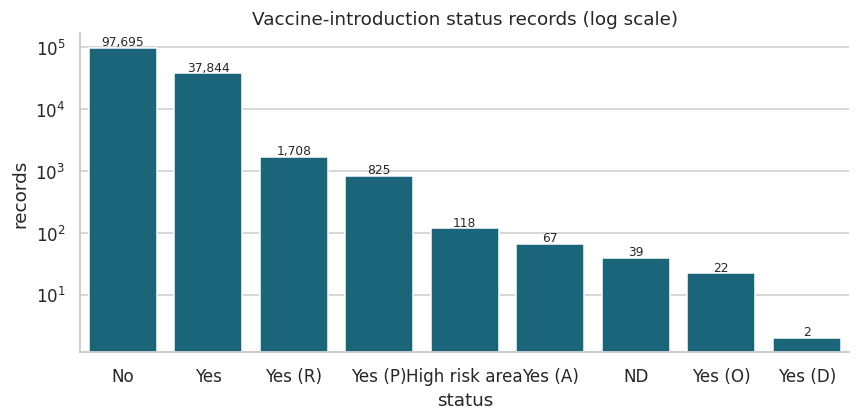

In [17]:
# Chart - 5 visualization code: how countries report vaccine introduction
status = intro["intro"].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=status.index, y=status.values, color=PALETTE[0], ax=ax)
ax.set_yscale("log")
for i, v in enumerate(status.values):
    ax.text(i, v * 1.1, f"{v:,}", ha="center", fontsize=8)
ax.set(title="Vaccine-introduction status records (log scale)", xlabel="status", ylabel="records")
plt.tight_layout(); plt.show()
yes_share = (intro["intro_flag"] == 1).sum() / intro["intro_flag"].notna().sum()
print(f"Share of country-year-vaccine records where the vaccine is in the programme: {yes_share:.1%}")
latest_intro = intro[intro["year"] == intro["year"].max()]
print(f"In {intro['year'].max()}: {(latest_intro['intro_flag'] == 1).mean():.1%} of country-vaccine pairs are introduced")

##### 1. Why did you pick the specific chart?

The introduction status is a categorical variable with many unequal categories, so a bar chart on a log axis shows all of them, including the rare partial and regional codes.

##### 2. What is/are the insight(s) found from the chart?

Most records are **No** (about 97,700 of 138,000), but this is because the table records every vaccine for every country-year from 1940. Only 29.4% of all records show a vaccine in the programme, but in 2023 **56.5%** of country-vaccine pairs are introduced. Partial forms exist (Yes (R) 1,708, Yes (P) 825, High risk area 118).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** adoption of vaccines keeps growing, and 56.5% of the possible introductions are done. **Negative:** the remaining pairs still show gaps, and partial or regional introductions (R, P, high-risk areas) can look like coverage when only part of the population is protected, so counting them as full introduction would overstate progress.

#### Chart - 6

antigen  DTPCV3  MCV1  MCV2
year                       
1980       20.0  16.0   NaN
1990       76.0  73.0   NaN
2000       72.0  71.0  17.0
2010       83.0  84.0  41.0
2019       86.0  86.0  71.0
2021       81.0  81.0  71.0
2023       84.0  83.0  74.0


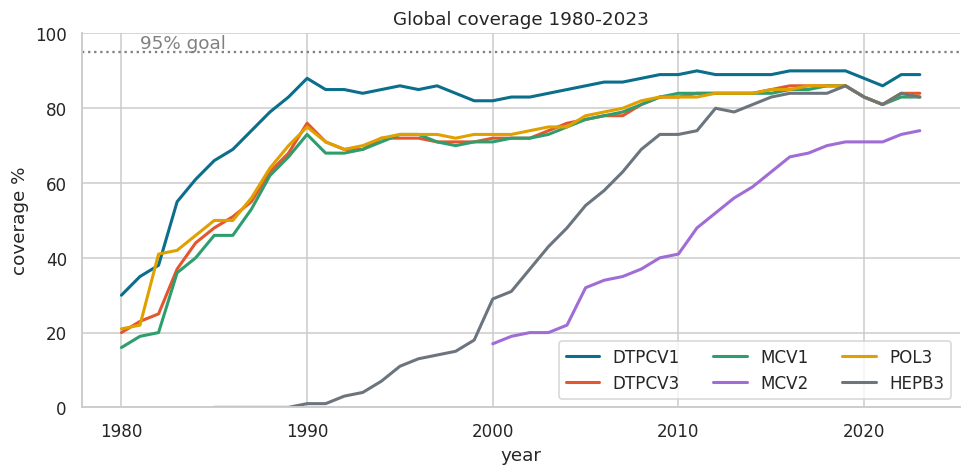

In [18]:
# Chart - 6 visualization code: global coverage trend of the core vaccines (WHO/UNICEF global aggregate)
glob = cov_group[(cov_group["code"] == "GLOBAL") & (cov_group["coverage_category"] == "WUENIC")]
fig, ax = plt.subplots(figsize=(9, 4.5))
for ag, col in zip(["DTPCV1", "DTPCV3", "MCV1", "MCV2", "POL3", "HEPB3"], PALETTE):
    d = glob[glob["antigen"] == ag].sort_values("year")
    ax.plot(d["year"], d["coverage"], label=ag, color=col, lw=2)
ax.axhline(95, color="grey", ls=":"); ax.text(1981, 96, "95% goal", color="grey")
ax.set(title="Global coverage 1980-2023", xlabel="year", ylabel="coverage %", ylim=(0, 100))
ax.legend(ncol=3)
plt.tight_layout(); plt.show()
piv = glob.pivot_table(index="year", columns="antigen", values="coverage")[["DTPCV3", "MCV1", "MCV2"]]
print(piv.loc[[1980, 1990, 2000, 2010, 2019, 2021, 2023]].to_string())

##### 1. Why did you pick the specific chart?

A line chart is the natural choice for a trend over time. Plotting the WHO/UNICEF global aggregate for the core vaccines shows both the long-term gain and recent setbacks, with the 95% goal as a reference line.

##### 2. What is/are the insight(s) found from the chart?

Global DTP3 coverage rose from 20% in 1980 to 76% in 1990 and 86% in 2019, then fell to 81% in 2021 and only recovered to 84% in 2023. Measles first-dose coverage followed the same path (16% to 86% to 83%). The second measles dose grew from 17% in 2000 to 74% in 2023. No vaccine has ever reached 95% globally.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a fourfold gain since 1980 proves that immunization programmes deliver at scale, which supports continued funding. **Negative:** coverage has been flat since 2010 and did not recover from the 2020-21 dip. Missing the 95% level leaves populations open to measles and pertussis outbreaks.

#### Chart - 7

Global average drop-off: 1980 37.2% | 2000 10.0% | 2019 4.9% | 2023 6.1%


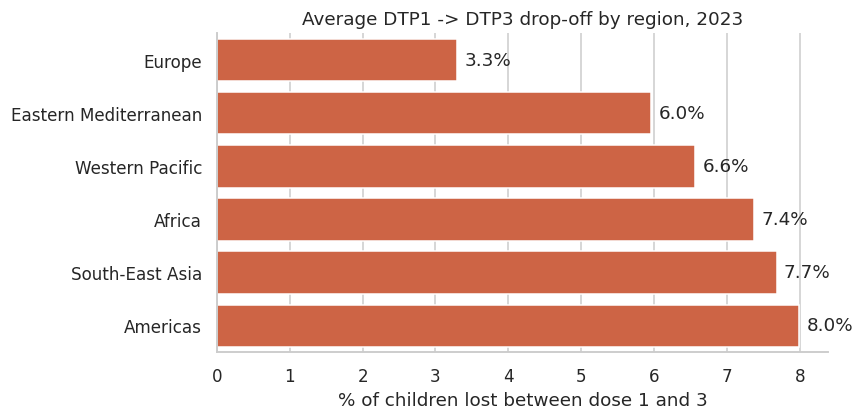

In [19]:
# Chart - 7 visualization code: DTP drop-off between the first and third dose by WHO region
d23 = panel[(panel["year"] == latest)].dropna(subset=["cov_DTPCV1", "cov_DTPCV3", "region"]).query("cov_DTPCV1 > 0")
d23 = d23.assign(dropoff=(d23["cov_DTPCV1"] - d23["cov_DTPCV3"]) / d23["cov_DTPCV1"] * 100)
drop = d23.groupby("region")["dropoff"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=drop.values, y=drop.index, color=PALETTE[1], ax=ax)
for i, v in enumerate(drop.values):
    ax.text(v + 0.1, i, f"{v:.1f}%", va="center")
ax.set(title=f"Average DTP1 -> DTP3 drop-off by region, {latest}", xlabel="% of children lost between dose 1 and 3", ylabel="")
plt.tight_layout(); plt.show()
hist_drop = panel.dropna(subset=["cov_DTPCV1", "cov_DTPCV3"]).query("cov_DTPCV1 > 0").assign(
    d=lambda x: (x["cov_DTPCV1"] - x["cov_DTPCV3"]) / x["cov_DTPCV1"] * 100).groupby("year")["d"].mean()
print(f"Global average drop-off: 1980 {hist_drop[1980]:.1f}% | 2000 {hist_drop[2000]:.1f}% | 2019 {hist_drop[2019]:.1f}% | {latest} {hist_drop[latest]:.1f}%")

##### 1. Why did you pick the specific chart?

A bar chart of the mean drop-off by region compares one derived metric across categories. Drop-off (dose 1 to dose 3) measures children who start vaccination but do not complete it, which is different from children never reached.

##### 2. What is/are the insight(s) found from the chart?

On average 37% of children who received DTP1 did not get DTP3 in 1980; this fell to 10% in 2000 and 4.9% in 2019, but **rose to 6.1% in 2023**. By region in 2023 the drop-off is highest in the Americas (8.0%), South-East Asia (7.7%) and Africa (7.4%) and lowest in Europe (3.3%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** drop-off is the cheapest gap to close because these children are already in the system: reminders, tracking of immunization cards and outreach can recover them. **Negative:** the increase since 2019 and the high level in the Americas, a high-coverage region, suggests complacency and weakened follow-up after the pandemic.

#### Chart - 8

n = 4,330 country-years, Spearman r = -0.317, p = 1.5e-101


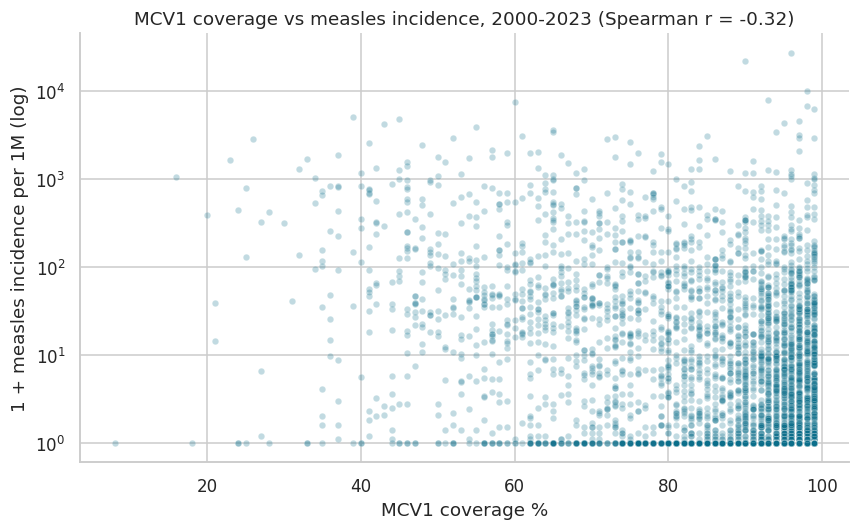

In [20]:
# Chart - 8 visualization code: measles coverage vs measles incidence (numerical vs numerical)
from scipy import stats
d = panel.dropna(subset=["cov_MCV1", "inc_MEASLES"]).query("year >= 2000")
r, p = stats.spearmanr(d["cov_MCV1"], d["inc_MEASLES"])
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=d, x="cov_MCV1", y=1 + d["inc_MEASLES"], alpha=0.25, s=18, color=PALETTE[0], ax=ax)
ax.set_yscale("log")
ax.set(title=f"MCV1 coverage vs measles incidence, 2000-2023 (Spearman r = {r:.2f})", xlabel="MCV1 coverage %", ylabel="1 + measles incidence per 1M (log)")
plt.tight_layout(); plt.show()
print(f"n = {len(d):,} country-years, Spearman r = {r:.3f}, p = {p:.1e}")

##### 1. Why did you pick the specific chart?

A scatter plot is the right chart for the relationship between two numeric variables. A log scale on incidence is used because of the skew, and Spearman correlation because the relationship is monotonic but not linear.

##### 2. What is/are the insight(s) found from the chart?

The relationship is negative (Spearman r = **-0.32**, n = 4,330 country-years since 2000): higher coverage goes with lower incidence. But the scatter is wide. At coverage above 90% incidence still ranges from zero to over 1,000 per million, so coverage explains only part of measles risk.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** supports investment in coverage as the main way to reduce measles. **Negative:** high national coverage does not guarantee protection; outbreaks in high-coverage countries point to unvaccinated pockets, waning immunity and surveillance differences, so funding should also be linked to district-level data, not only national coverage.

#### Chart - 9

           count    mean  median
mcv1_band                       
<50%         881  1476.2   400.6
50-79%      1893   611.3    63.2
80-89%      1468   253.1     8.6
90-94%      1279   135.5     2.1
95%+        1759   179.8     1.0


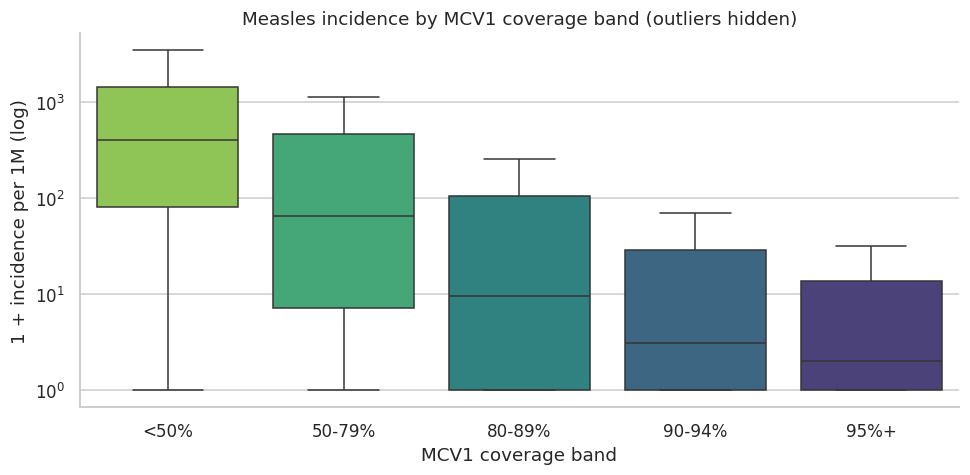

In [21]:
# Chart - 9 visualization code: measles incidence by MCV1 coverage band (categorical vs numerical)
d = panel.dropna(subset=["mcv1_band", "inc_MEASLES"])
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.boxplot(data=d, x="mcv1_band", y=1 + d["inc_MEASLES"], palette="viridis_r", showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set(title="Measles incidence by MCV1 coverage band (outliers hidden)", xlabel="MCV1 coverage band", ylabel="1 + incidence per 1M (log)")
plt.tight_layout(); plt.show()
band = d.groupby("mcv1_band")["inc_MEASLES"].agg(["count", "mean", "median"]).round(1)
print(band.to_string())

##### 1. Why did you pick the specific chart?

A box plot compares the distribution of a numeric variable (incidence) across ordered categories (coverage bands). Medians are more reliable than means here because of outliers.

##### 2. What is/are the insight(s) found from the chart?

The median measles incidence falls from **400 per million** where MCV1 coverage is below 50% to 63 (50-79%), 8.6 (80-89%), 2.1 (90-94%) and **1.0** at 95% or more. The largest drop happens when moving above 80% (median from 63 to 8.6). The mean at 95%+ (180) is higher than at 90-94% (136) because a few outbreak countries are included.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a clear dose-response: every step up in coverage brings a sharp fall in incidence, giving a measurable return on raising a country from below 80% to above 90%. **Negative:** 1,759 country-years at 95%+ still include outbreaks, so the 95% national target alone is not enough without protecting every district.

#### Chart - 10

                early      late    n  reduction_pct
disease                                            
DIPHTHERIA    64102.4   21993.6  169           65.7
NTETANUS      19462.7    2478.0  136           87.3
TTETANUS     105551.3   13158.8  170           87.5
MEASLES     3584608.0  376448.1  170           89.5
PERTUSSIS   1509916.6   82747.6  161           94.5
POLIO         49176.4     771.7  162           98.4


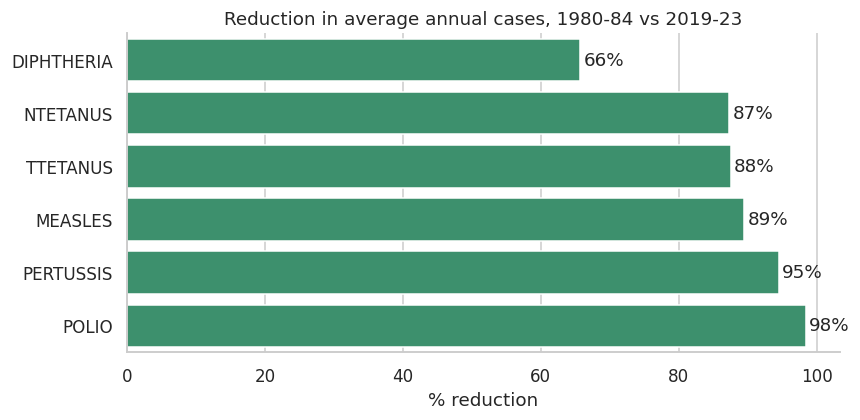

In [22]:
# Chart - 10 visualization code: change in reported cases, 1980-84 vs 2019-23 (same countries)
def period_mean(years):
    return cas_c[cas_c["year"].between(*years)].groupby(["code", "disease"])["cases"].mean()

early, late = period_mean((1980, 1984)), period_mean((2019, 2023))
both = pd.concat([early.rename("early"), late.rename("late")], axis=1).dropna().reset_index()
red = both.groupby("disease")[["early", "late"]].sum().assign(n=both.groupby("disease").size())
red["reduction_pct"] = (red["early"] - red["late"]) / red["early"] * 100
red = red[(red["early"] > 0) & (red["n"] >= 30)].sort_values("reduction_pct")
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=red["reduction_pct"], y=red.index, color=PALETTE[2], ax=ax)
for i, v in enumerate(red["reduction_pct"]):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center")
ax.set(title="Reduction in average annual cases, 1980-84 vs 2019-23", xlabel="% reduction", ylabel="")
plt.tight_layout(); plt.show()
print(red.round(1).to_string())

##### 1. Why did you pick the specific chart?

A bar chart of percentage reduction shows the change between two periods for several diseases at once. Only countries reporting in both periods are used so the comparison is like-for-like.

##### 2. What is/are the insight(s) found from the chart?

Average annual reported cases fell by **98.4% for polio** (49,176 to 772), 94.5% for pertussis, 89.5% for measles (3.58 million to 376,000), about 87% for tetanus (adult and neonatal) and 65.7% for diphtheria, in 136 to 170 countries per disease.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** strong evidence of impact, useful for justifying budgets and new vaccine introductions. **Negative:** diphtheria improved least (-66%) and measles still has about 376,000 cases a year, showing programme gaps. Part of the change also comes from better or worse reporting over 40 years, so the numbers should be seen as approximate.

#### Chart - 11

Total zero-dose children: 15.2 million


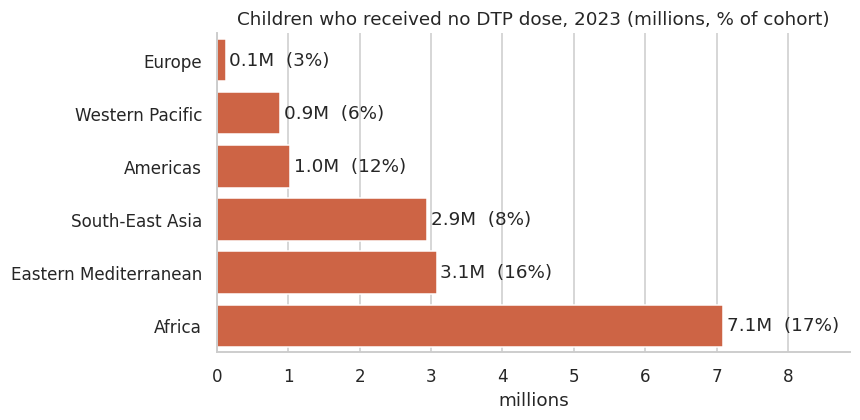

In [23]:
# Chart - 11 visualization code: zero-dose children by WHO region
zd = panel[panel["year"] == latest].dropna(subset=["zero_dose_children", "region"]).groupby("region")["zero_dose_children"].sum().sort_values()
tot = panel[panel["year"] == latest].dropna(subset=["target_number", "cov_DTPCV1", "region"]).groupby("region")["target_number"].sum()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=zd.values / 1e6, y=zd.index, color=PALETTE[1], ax=ax)
for i, (reg, v) in enumerate(zd.items()):
    ax.text(v / 1e6 + 0.05, i, f"{v / 1e6:.1f}M  ({v / tot[reg]:.0%})", va="center")
ax.set(title=f"Children who received no DTP dose, {latest} (millions, % of cohort)", xlabel="millions", ylabel="")
ax.set_xlim(0, zd.max() / 1e6 * 1.25)
plt.tight_layout(); plt.show()
print(f"Total zero-dose children: {zd.sum() / 1e6:.1f} million")

##### 1. Why did you pick the specific chart?

A bar chart is used to compare a total across regions. Zero-dose children (no DTP dose at all) are shown in absolute numbers and as a share of the birth cohort, because the two views give different priorities.

##### 2. What is/are the insight(s) found from the chart?

About **15.2 million children** received no DTP dose in 2023 (an estimate built from administrative targets and official coverage). Africa has 7.1 million (17.3% of its cohort) and the Eastern Mediterranean 3.1 million (16.3%), together 67% of the total. South-East Asia has 2.9 million (8.1%), the Americas 1.0 million (11.8%), the Western Pacific 0.9 million and Europe 0.1 million.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** shows exactly where to send outreach: two regions hold two thirds of unreached children. **Negative:** the Americas has almost 12% of children unreached, higher than expected, and South-East Asia has a small share but a large absolute number. Without action zero-dose children carry the risk of the next outbreaks.

#### Chart - 12

vaccine                   HPV  Measles 2nd dose  Rotavirus  Rubella
region                                                             
Africa                 2018.6            2013.5     2014.4   2015.8
Americas               2014.8            2001.8     2009.9   1993.5
Eastern Mediterranean  2019.5            1998.5     2013.7   1997.4
Europe                 2013.1            1992.4     2014.9   1995.9
South-East Asia        2016.3            2007.5     2019.0   2009.4
Western Pacific        2015.3            2001.8     2015.8   2002.0


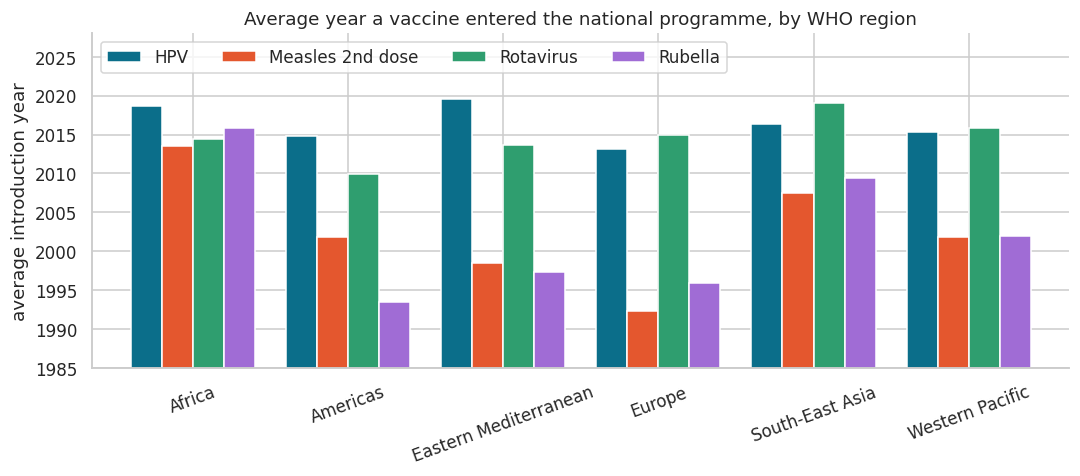

In [24]:
# Chart - 12 visualization code: when did each region introduce four newer vaccines? (categorical vs categorical)
targets = {"Measles 2nd dose": "Measles-containing vaccine 2nd dose", "Rubella": "Rubella vaccine",
           "Rotavirus": "Rotavirus vaccine", "HPV": "HPV (Human Papilloma Virus) vaccine"}
first = (intro[(intro["intro_flag"] == 1) & intro["description"].isin(targets.values())]
         .groupby(["iso_3_code", "description"])["year"].min().reset_index()
         .merge(countries[["code", "region"]], left_on="iso_3_code", right_on="code"))
first = first[first["year"] > 1980]          # earlier records are legacy programmes with no visible start year
first["vaccine"] = first["description"].map({v: k for k, v in targets.items()})
tab = first.groupby(["region", "vaccine"])["year"].mean().unstack().round(1)
tab.plot(kind="bar", figsize=(10, 4.5), color=PALETTE[:4], width=0.8)
plt.ylim(1985, 2028); plt.ylabel("average introduction year"); plt.xlabel("")
plt.title("Average year a vaccine entered the national programme, by WHO region"); plt.xticks(rotation=20)
plt.legend(ncol=4, loc="upper left"); plt.tight_layout(); plt.show()
print(tab.to_string())

##### 1. Why did you pick the specific chart?

A grouped bar chart compares two categorical variables (region and vaccine) through one numeric value, the average year of introduction, so regional lags become visible.

##### 2. What is/are the insight(s) found from the chart?

Europe introduced the second measles dose on average in 1992, Africa in 2013 (21 years later). Rubella entered the Americas in 1993 but Africa in 2016. HPV reached Europe in 2013 and the Eastern Mediterranean in 2019. Rotavirus was introduced in the Americas in 2010 but in South-East Asia only in 2019.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** identifies where introduction support (co-financing, Gavi, technical help) can shorten the wait for new vaccines. **Negative:** delays of 10-20 years mean years of preventable disease in the regions that need vaccines most, which increases outbreak and treatment costs.

#### Chart - 13

antigen  DIPHCV4  DIPHCV5  DIPHCV6  PERCV4  TTCV4  TTCV5
year                                                    
2018        85.6     82.0     80.6    84.8   84.1   81.4
2019        87.4     84.1     80.0    86.9   86.6   83.5
2020        82.4     78.5     72.8    82.0   81.8   77.6
2021        83.3     78.8     74.7    82.8   83.6   76.7
2022        83.5     79.3     78.6    84.1   83.1   77.9
2023        84.4     81.7     78.6    84.2   82.5   79.5


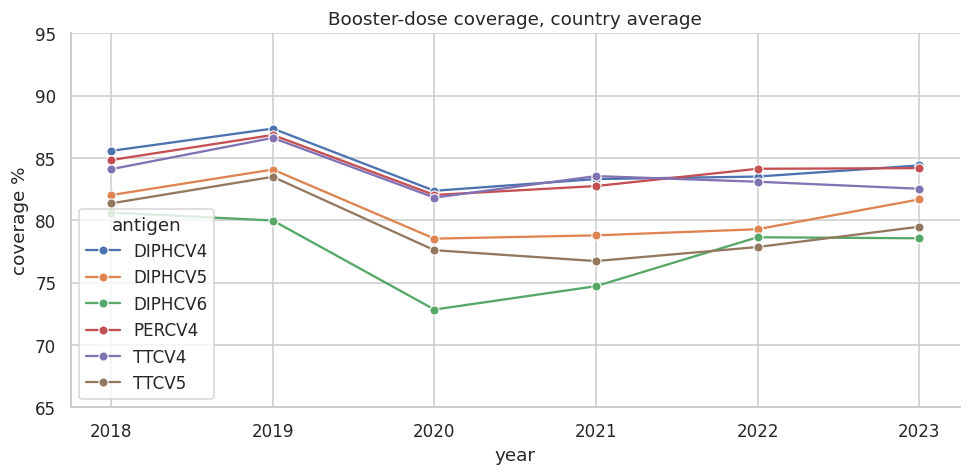

In [25]:
# Chart - 13 visualization code: booster-dose coverage over time (official statistics, available from 2018)
boost = cov_country[(cov_country["coverage_category"] == "OFFICIAL") & cov_country["antigen"].isin(["DIPHCV4", "DIPHCV5", "DIPHCV6", "PERCV4", "TTCV4", "TTCV5"])]
trend = boost.groupby(["antigen", "year"])["coverage_capped"].mean().reset_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(data=trend, x="year", y="coverage_capped", hue="antigen", marker="o", ax=ax)
ax.set(title="Booster-dose coverage, country average", ylabel="coverage %", xlabel="year", ylim=(65, 95))
plt.tight_layout(); plt.show()
print(trend.pivot(index="year", columns="antigen", values="coverage_capped").round(1).to_string())

##### 1. Why did you pick the specific chart?

A multi-line chart shows how several related measures move over time, so one can see whether booster coverage is improving and how it compares across dose numbers.

##### 2. What is/are the insight(s) found from the chart?

Booster data exist only from 2018. The 4th DTP dose fell from 87.4% (2019) to 82.4% (2020) and is 84.4% in 2023; the 6th dose fell from 80.6% to 72.8% and is at 78.6%. Coverage drops with each later dose (84.4% for dose 4, 81.7% dose 5, 78.6% dose 6). In 2023 every booster is still below 2019, so **there is no upward trend**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the trend can now be tracked and points to a clear target (restore 2019 levels and raise later doses). **Negative:** school-age boosters are slipping, which risks pertussis and diphtheria in older children and reduces herd protection for infants.

#### Chart - 14 - Correlation Heatmap

            inc_MEASLES  inc_PERTUSSIS  inc_DIPHTHERIA  inc_POLIO  inc_TTETANUS
cov_BCG           -0.42          -0.37           -0.33      -0.32         -0.44
cov_DTPCV1        -0.44          -0.28           -0.35      -0.34         -0.50
cov_DTPCV3        -0.47          -0.30           -0.37      -0.34         -0.52
cov_MCV1          -0.49          -0.28           -0.33      -0.35         -0.52
cov_MCV2          -0.09           0.06           -0.13      -0.25         -0.23
cov_POL3          -0.45          -0.28           -0.36      -0.35         -0.52
cov_HEPB3         -0.25          -0.11           -0.23      -0.29         -0.34
cov_HIB3          -0.24          -0.02           -0.20      -0.29         -0.32


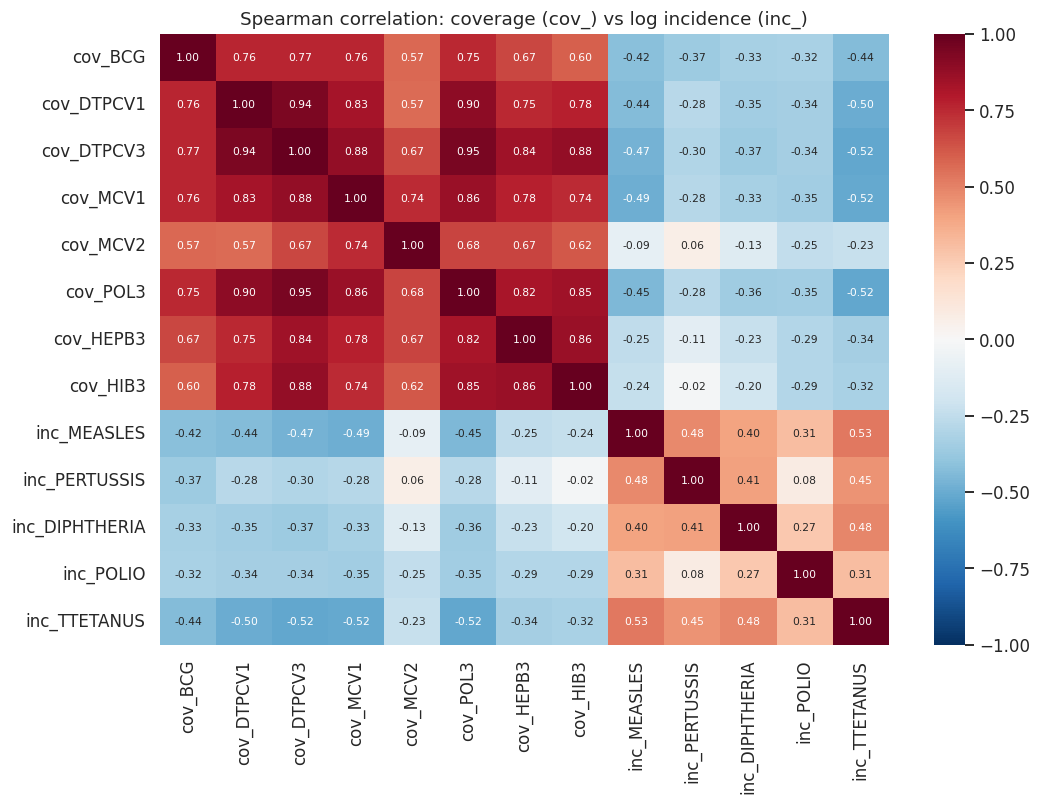

In [26]:
# Correlation Heatmap visualization code
num_cols = ["cov_BCG", "cov_DTPCV1", "cov_DTPCV3", "cov_MCV1", "cov_MCV2", "cov_POL3", "cov_HEPB3", "cov_HIB3",
            "inc_MEASLES", "inc_PERTUSSIS", "inc_DIPHTHERIA", "inc_POLIO", "inc_TTETANUS"]
corr_df = panel[num_cols].copy()
inc_cols = [c for c in num_cols if c.startswith("inc_")]
corr_df[inc_cols] = np.log10(1 + corr_df[inc_cols])                # incidence is heavily skewed: correlate on the log scale
corr = corr_df.corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot_kws={"size": 7}, ax=ax)
ax.set_title("Spearman correlation: coverage (cov_) vs log incidence (inc_)")
plt.tight_layout(); plt.show()
print(corr.loc[[c for c in num_cols if c.startswith("cov_")], inc_cols].round(2).to_string())

##### 1. Why did you pick the specific chart?

A correlation heatmap summarises the relationships between many numeric variables in one view. Spearman (rank) correlation is used with log-transformed incidence because the variables are skewed and the relationships are not linear.

##### 2. What is/are the insight(s) found from the chart?

Coverage of different vaccines is highly correlated (DTP3 and POL3 0.95, DTP3 and MCV1 0.88, HepB3 and DTP3 0.84): countries that vaccinate well do so for all vaccines. Coverage and incidence are negatively correlated. The strongest links are tetanus (-0.52 with DTP3 and MCV1) and measles (-0.49 with MCV1). The weakest are for MCV2 (about -0.09 for measles and +0.06 for pertussis) and for hepatitis B and Hib versus pertussis (-0.11 and -0.02). Correlation is not proof of causation.

#### Chart - 15 - Pair Plot

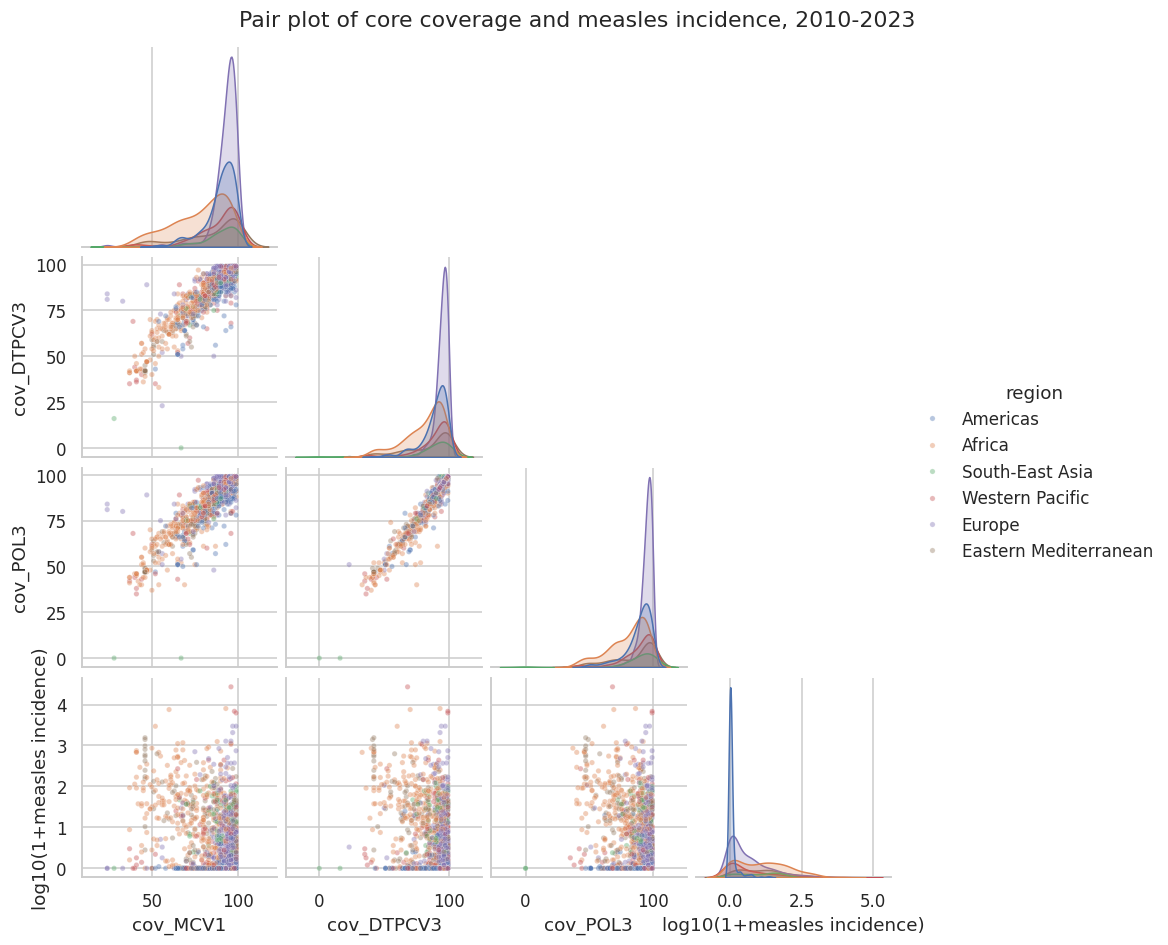

In [27]:
# Pair Plot visualization code
pp = panel[panel["year"] >= 2010].dropna(subset=["cov_MCV1", "cov_DTPCV3", "cov_POL3", "inc_MEASLES", "region"]).copy()
pp["log10(1+measles incidence)"] = log_inc(pp["inc_MEASLES"])
cols = ["cov_MCV1", "cov_DTPCV3", "cov_POL3", "log10(1+measles incidence)"]
g = sns.pairplot(pp.sample(min(1500, len(pp)), random_state=1), vars=cols, hue="region", plot_kws={"alpha": 0.4, "s": 12}, corner=True, height=2.1)
g.fig.suptitle("Pair plot of core coverage and measles incidence, 2010-2023", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows the pairwise scatter and the distribution of several variables at once, and colouring by region adds a third dimension. It is used to check linearity, clusters and outliers before any modelling.

##### 2. What is/are the insight(s) found from the chart?

The coverage variables lie close to a diagonal line (DTP3 vs POL3 almost perfectly linear), showing they are one system. Against incidence there is a wide scatter: very high incidence (above about 1,000 per million) is most common where coverage is below 80%, and Africa (orange) clusters at lower coverage, while at 90-100% coverage most points sit near zero incidence with a scatter of outbreak country-years. So coverage lowers risk but does not remove it, and the outlier countries at high coverage need separate investigation.

#### Chart - 16

Lowest region for each vaccine:
BCG       Eastern Mediterranean
DTPCV3                   Africa
MCV1                     Africa
MCV2                     Africa
POL3                     Africa
HEPB3                    Africa
HIB3                     Africa
PCV3            South-East Asia
ROTAC           South-East Asia


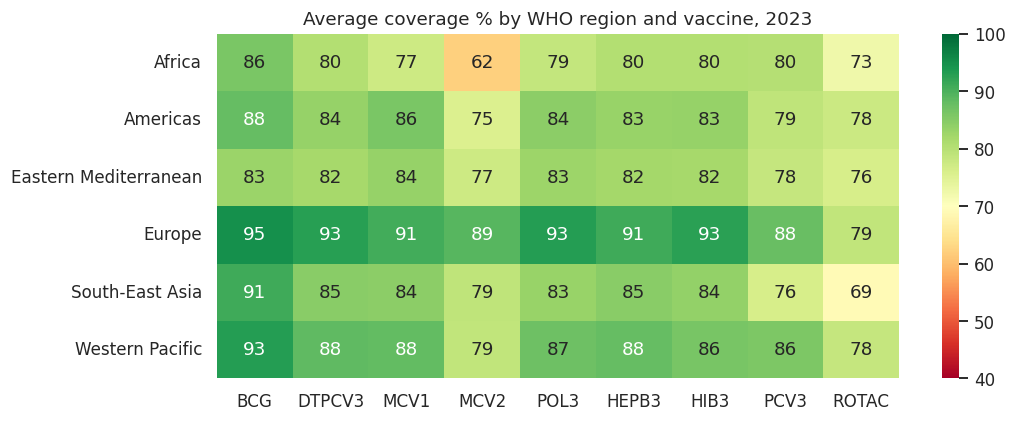

In [28]:
# Chart - 16 visualization code: region x vaccine coverage matrix (multivariate)
mat = (panel[panel["year"] == latest].dropna(subset=["region"])
       .groupby("region")[["cov_BCG", "cov_DTPCV3", "cov_MCV1", "cov_MCV2", "cov_POL3", "cov_HEPB3", "cov_HIB3", "cov_PCV3", "cov_ROTAC"]].mean())
mat.columns = [c.replace("cov_", "") for c in mat.columns]
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(mat, annot=True, fmt=".0f", cmap="RdYlGn", vmin=40, vmax=100, ax=ax)
ax.set(title=f"Average coverage % by WHO region and vaccine, {latest}", ylabel="")
plt.tight_layout(); plt.show()
print("Lowest region for each vaccine:"); print(mat.idxmin().to_string())

##### 1. Why did you pick the specific chart?

A heatmap of region by vaccine lets us compare two categorical variables and a numeric value in one picture. The colour scale (red to green) makes gaps visible at once.

##### 2. What is/are the insight(s) found from the chart?

Africa has the lowest coverage for most core vaccines (DTP3 80%, MCV1 77%, second measles dose **62%** versus 89% in Europe, a 27-point gap). South-East Asia is lowest for the pneumococcal (76%) and rotavirus (69%) vaccines, and the Eastern Mediterranean for BCG (83%). Europe is the highest region for every vaccine, yet even there rotavirus reaches only 79%. Rotavirus is below 80% in every region.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** allows a tailored strategy: routine core vaccines and MCV2 in Africa, newer vaccines in South-East Asia. **Negative:** no region is strong in rotavirus (69-79%), so a whole class of new vaccines is under-delivered and children stay exposed to severe diarrhoea.

#### Chart - 17

                         country  cov_MCV1  inc_MEASLES  cases_MEASLES
Democratic Republic of the Congo      65.0       3583.0       333017.0
                      Madagascar      60.0       7556.0       213231.0
                         Ukraine      93.0       1274.0        57282.0
                     Philippines      83.0        438.0        48525.0
                         Nigeria      58.0        134.0        28094.0


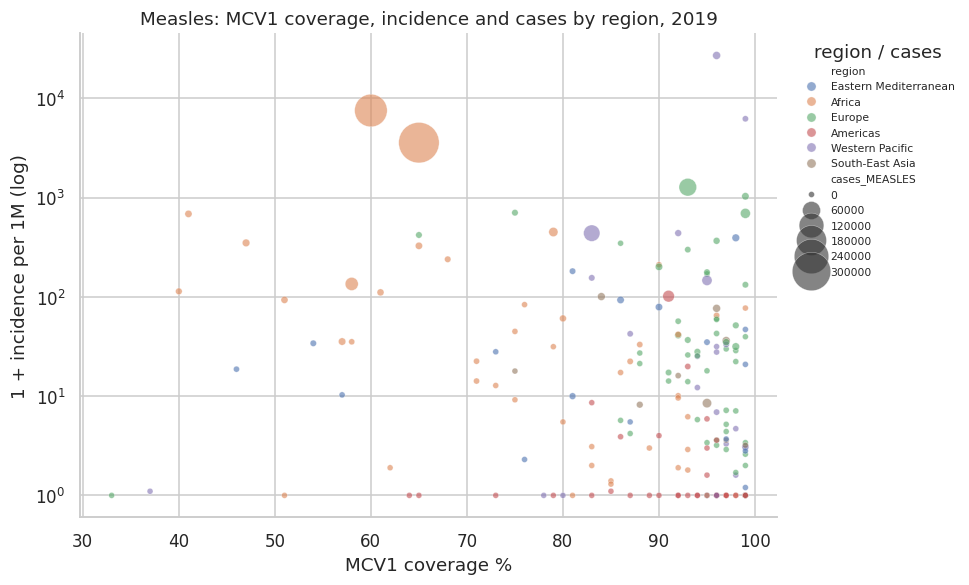

In [29]:
# Chart - 17 visualization code: coverage vs incidence vs burden vs region (bubble scatter, one year)
YEAR = 2019   # last year before COVID-19 disruption
d = panel[(panel["year"] == YEAR)].dropna(subset=["cov_MCV1", "inc_MEASLES", "cases_MEASLES", "region"])
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=d, x="cov_MCV1", y=1 + d["inc_MEASLES"], size="cases_MEASLES", sizes=(15, 700), hue="region", alpha=0.6, ax=ax)
ax.set_yscale("log")
ax.set(title=f"Measles: MCV1 coverage, incidence and cases by region, {YEAR}", xlabel="MCV1 coverage %", ylabel="1 + incidence per 1M (log)")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7, title="region / cases", frameon=False)
plt.tight_layout(); plt.show()
print(d.nlargest(5, "cases_MEASLES")[["country", "cov_MCV1", "inc_MEASLES", "cases_MEASLES"]].round(0).to_string(index=False))

##### 1. Why did you pick the specific chart?

A bubble scatter shows four variables at once: coverage (x), incidence (y), number of cases (bubble size) and region (colour). 2019 is used as the last year before COVID-19 disruption.

##### 2. What is/are the insight(s) found from the chart?

Africa accounted for about **71%** of measles cases in 2019 (618,595 of 873,730). The DR Congo had 333,017 cases with MCV1 at 65% and Madagascar 213,231 cases at 60%, the two largest bubbles. Ukraine (57,282 cases) and the Philippines (48,525) show that big outbreaks also occur at higher coverage (93% and 83%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** a handful of countries cause most measles cases, so focused campaigns in the DR Congo, Madagascar and Nigeria would cut the global burden quickly. **Negative:** Ukraine shows that conflict or pockets of unvaccinated people can cause large outbreaks even at 93% national coverage, so a national average is not a safe metric.

#### Chart - 18

antigen        DTPCV3  MCV1  MCV2
income                           
Low income       68.0  64.0  42.0
Lower-middle     85.0  85.0  77.0
Upper-middle     90.0  90.0  82.0
High non-OECD    95.0  95.0  93.0
High OECD        94.0  93.0  91.0

Gap high-income OECD minus low-income (points):
antigen
DTPCV3    26.0
MCV1      29.0
MCV2      49.0


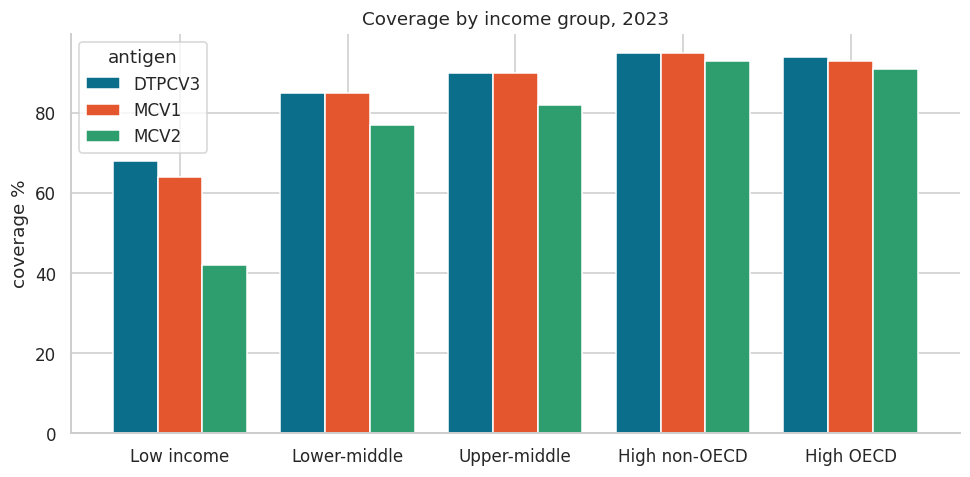

In [30]:
# Chart - 18 visualization code: coverage gaps by World Bank income group (group aggregates in the coverage file)
inc_map = {"WB_LONG_LIC": "Low income", "WB_LONG_LMIC": "Lower-middle", "WB_LONG_UMIC": "Upper-middle",
           "WB_LONG_HIC_NONOECD": "High non-OECD", "WB_LONG_HIC_OECD": "High OECD"}
g = cov_group[(cov_group["group"] == "WB_LONG") & (cov_group["coverage_category"] == "WUENIC") & (cov_group["year"] == latest)
              & cov_group["code"].isin(inc_map) & cov_group["antigen"].isin(["DTPCV3", "MCV1", "MCV2"])]
g = g.assign(income=g["code"].map(inc_map)).pivot(index="income", columns="antigen", values="coverage").loc[list(inc_map.values())]
g.plot(kind="bar", figsize=(9, 4.5), color=PALETTE[:3], width=0.8)
plt.ylabel("coverage %"); plt.xlabel(""); plt.xticks(rotation=0); plt.title(f"Coverage by income group, {latest}")
plt.tight_layout(); plt.show()
print(g.to_string()); print("\nGap high-income OECD minus low-income (points):"); print((g.loc["High OECD"] - g.loc["Low income"]).to_string())

##### 1. Why did you pick the specific chart?

Grouped bars compare a numeric outcome (coverage) for several vaccines across ordered income groups. The World Bank income aggregates are the only socioeconomic variable in the data.

##### 2. What is/are the insight(s) found from the chart?

In 2023 low-income countries have DTP3 at 68%, MCV1 at 64% and MCV2 at only **42%**, versus 94%, 93% and 91% in high-income OECD countries: gaps of 26, 29 and **49 points**. The gradient is steady through lower-middle and upper-middle income; high-income non-OECD countries are slightly higher than OECD countries (95%, 95%, 93%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the widest gap (MCV2) shows where financing gives the largest return, so donors can target low-income co-financing. **Negative:** with MCV2 at 42% low-income countries are exposed to measles outbreaks. The data are group totals, so inequality inside countries (rural, poor, minority) cannot be seen and probably is larger.

#### Chart - 19

Top 15 hold 71% of all zero-dose children
                         country  cov_DTPCV1  zero_dose_children
                         Nigeria        70.0           2531650.0
                           India        93.0           1860341.0
Democratic Republic of the Congo        80.0            864524.0
                           Sudan        57.0            812862.0
                        Ethiopia        77.0            787739.0
                       Indonesia        85.0            652341.0


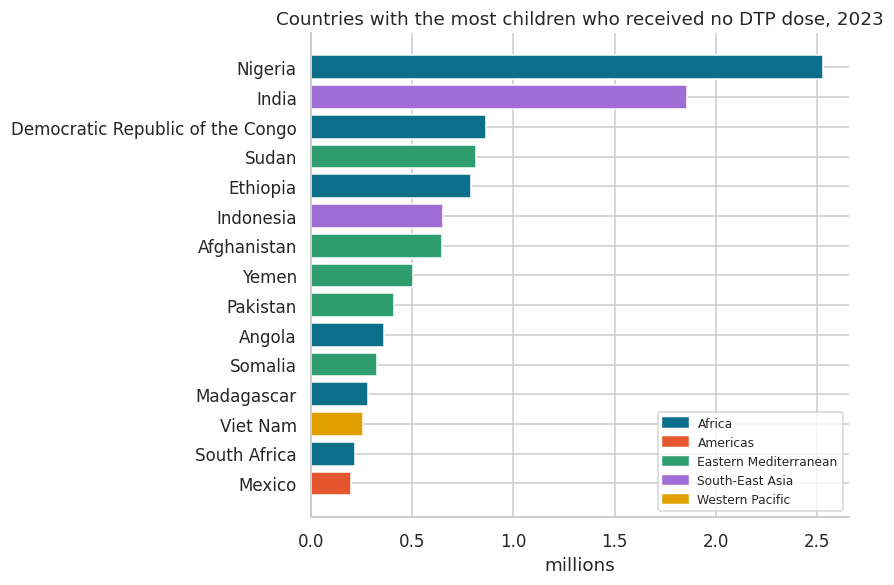

In [31]:
# Chart - 19 visualization code: the 15 countries with the most zero-dose children
top = panel[panel["year"] == latest].dropna(subset=["zero_dose_children"]).nlargest(15, "zero_dose_children").iloc[::-1]
regions = sorted(top["region"].dropna().unique())
colors = top["region"].map(dict(zip(regions, PALETTE)))
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top["country"], top["zero_dose_children"] / 1e6, color=colors)
ax.set(title=f"Countries with the most children who received no DTP dose, {latest}", xlabel="millions")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in PALETTE[:len(regions)]]
ax.legend(handles, regions, loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()
print(f"Top 15 hold {top['zero_dose_children'].sum() / panel[panel['year'] == latest]['zero_dose_children'].sum():.0%} of all zero-dose children")
print(top.sort_values("zero_dose_children", ascending=False)[["country", "cov_DTPCV1", "zero_dose_children"]].round(0).head(6).to_string(index=False))

##### 1. Why did you pick the specific chart?

A ranked horizontal bar chart is the clearest way to compare individual countries on one measure. Colour by region adds context.

##### 2. What is/are the insight(s) found from the chart?

Nigeria has the most zero-dose children (**2.5 million**, DTP1 coverage 70%), then India (1.9 million but 93% coverage), the DR Congo (0.86 million), Sudan (0.81 million) and Ethiopia (0.79 million). The 15 countries shown hold **71%** of all zero-dose children. India shows that a country with high coverage can still have a huge number of unreached children because of its size.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** concentrating support on 15 countries can reach most unvaccinated children. **Negative:** the list combines two different problems: low-coverage fragile settings (Sudan 57%, Yemen) that need conflict-sensitive delivery, and very large countries with high coverage (India, Indonesia) that need pocket-level micro-planning, so one strategy will not work for both.

#### Chart - 20

region  Africa  Americas  Eastern Mediterranean  Europe  South-East Asia  Western Pacific
year                                                                                     
1985    3437.0     398.0                 1414.0   761.0           1441.0           3809.0
2000     735.0       4.0                   93.0    27.0            243.0            153.0
2010     339.0       0.0                   19.0    65.0             21.0             10.0
2019     308.0       4.0                   48.0   126.0             26.0           1199.0
2023     187.0       0.0                  128.0    72.0             19.0              9.0


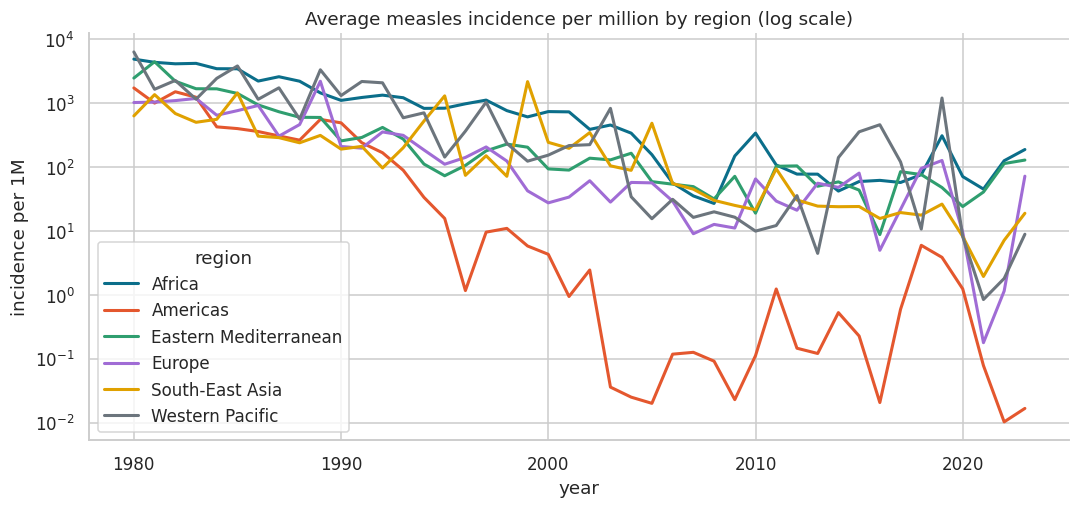

In [32]:
# Chart - 20 visualization code: measles incidence trend by WHO region, 1980-2023
tr = panel.dropna(subset=["region", "inc_MEASLES"]).groupby(["region", "year"])["inc_MEASLES"].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.lineplot(data=tr, x="year", y="inc_MEASLES", hue="region", palette=PALETTE, lw=2, ax=ax)
ax.set_yscale("log")
ax.set(title="Average measles incidence per million by region (log scale)", xlabel="year", ylabel="incidence per 1M")
plt.tight_layout(); plt.show()
print(tr[tr["year"].isin([1985, 2000, 2010, 2019, 2023])].pivot(index="year", columns="region", values="inc_MEASLES").round(0).to_string())

##### 1. Why did you pick the specific chart?

A multi-line chart on a log axis shows how average measles incidence evolves in each region over 44 years, for an outcome that ranges over several orders of magnitude.

##### 2. What is/are the insight(s) found from the chart?

Every region improved sharply since 1985 (Africa from 3,437 to 187 per million, the Western Pacific 3,809 to 9, the Americas 398 to about 0). But there were setbacks: the Western Pacific spiked to 1,199 in 2019, Europe rose from 65 (2010) to 126 (2019), and the Eastern Mediterranean increased from 19 in 2010 to 128 in 2023. Africa is still by far the highest in absolute cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the Americas (about zero) shows that elimination is achievable. **Negative:** the resurgence after 2010 in several regions is a warning that gains can be lost quickly when coverage slips. These are averages of country values, so small outbreak countries can dominate a region's line.

#### Chart - 21

         at_95             below_80            
vaccine DTPCV3  MCV1  MCV2   DTPCV3  MCV1  MCV2
year                                           
2000      33.9  28.6  42.1     29.2  33.3  28.1
2010      43.8  45.4  40.5     18.6  21.1  23.8
2019      44.1  44.6  28.2     17.9  19.0  33.3
2021      31.8  30.3  19.1     25.6  30.8  40.4
2023      34.4  34.4  18.9     24.1  25.1  41.1


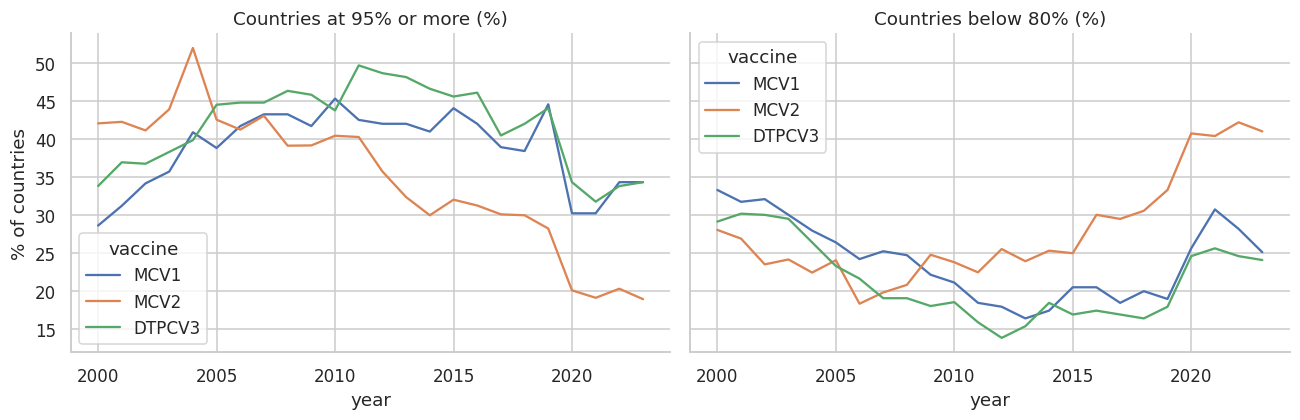

In [33]:
# Chart - 21 visualization code: progress against the 95% target - share of countries at or above 95% and below 80%
rows = []
for ag in ["cov_MCV1", "cov_MCV2", "cov_DTPCV3"]:
    s = panel.dropna(subset=[ag]).groupby("year")[ag]
    rows.append(pd.DataFrame({"year": s.size().index, "vaccine": ag.replace("cov_", ""),
                              "at_95": s.apply(lambda x: (x >= 95).mean() * 100).values,
                              "below_80": s.apply(lambda x: (x < 80).mean() * 100).values}))
prog = pd.concat(rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(data=prog[prog["year"] >= 2000], x="year", y="at_95", hue="vaccine", ax=axes[0]); axes[0].set(title="Countries at 95% or more (%)", ylabel="% of countries")
sns.lineplot(data=prog[prog["year"] >= 2000], x="year", y="below_80", hue="vaccine", ax=axes[1]); axes[1].set(title="Countries below 80% (%)", ylabel="")
plt.tight_layout(); plt.show()
print(prog[prog["year"].isin([2000, 2010, 2019, 2021, latest])].round(1).pivot(index="year", columns="vaccine", values=["at_95", "below_80"]).to_string())

##### 1. Why did you pick the specific chart?

Two side-by-side line charts track the same vaccines against the 95% goal (share of countries at or above 95%) and against a warning level (share below 80%), to show progress and risk together.

##### 2. What is/are the insight(s) found from the chart?

Countries reaching 95% for MCV1 rose from 28.6% (2000) to 45.4% (2010) and 44.6% (2019), then fell to 30.3% (2021) and 34.4% (2023). Countries below 80% have risen since 2019 for all three vaccines: MCV1 19.0% to 25.1%, DTP3 17.9% to 24.1% and MCV2 33.3% to **41.1%**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** the trend was upward for two decades, so recovery is possible with targeted effort. **Negative:** the 2030 measles goal of 95% is out of reach at the current pace; with 41% of countries below 80% for MCV2, larger outbreaks and higher treatment and emergency costs should be expected.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Recommendations for the client (public-health agency / funders)**

1. **Concentrate resources on zero-dose children.** About 15 million children got no DTP dose in 2023, two thirds in Africa and the Eastern Mediterranean and 71% in 15 countries (Nigeria, India, DR Congo, Sudan and Ethiopia first). Use different delivery models for fragile, low-coverage countries and for large high-coverage countries with local pockets.
2. **Close the drop-off and booster gaps.** Losing 6% of children between DTP1 and DTP3 and having boosters below 2019 levels is a cheap problem to fix with reminder systems, immunization-card tracking and school-entry checks.
3. **Make the second measles dose and newer vaccines a priority.** MCV2 (62% in Africa, 42% in low-income countries) and rotavirus (below 80% everywhere) have the largest gaps. Co-finance introduction and delivery, and shorten introduction delays of 10-20 years.
4. **Monitor pockets, not only national averages.** Outbreaks occurred at 90%+ coverage. Fund district-level reporting, report population-weighted results and set alerts on outbreak country-years (incidence above about 400 per million).
5. **Plan for the 2030 target.** Coverage has been flat since 2019 (MCV1 83%), so a recovery plan with yearly milestones (for example, halve the countries under 80%) is needed for measles.
6. **Improve the data.** Add sub-national, gender, education and urban/rural fields, monthly dates (for seasonality) and delivery-strategy information; these are missing from the current tables.

# **Conclusion**

Vaccination programmes have delivered enormous benefits: coverage rose from about 20% to 84-86% globally, and reported cases fell by 90-98% for polio, pertussis and measles. Higher coverage clearly goes with lower disease (median measles incidence 400 per million below 50% MCV1 coverage versus 1 per million at 95% or more), with the largest gain when coverage passes about 80-90%.

But progress has stalled and in some areas reversed. Global coverage has been flat since 2010 and did not recover from 2020, the drop-off between doses and the number of countries below 80% are rising, and boosters and the second measles dose lag. The problem is concentrated: 15 countries hold 71% of the 15 million zero-dose children, Africa has the lowest coverage and had 71% of measles cases in 2019, and low-income countries trail rich ones by up to 49 points. High national coverage is not enough either, as shown by outbreaks in countries above 90%.

The analysis, the cleaned SQL database and the Power BI dashboard together give decision makers a way to find the priority countries and vaccines, monitor the drop-off and coverage bands, and track the 95% goal. The limits of the data (no gender, education, urban/rural, monthly or delivery-strategy fields; incomplete surveillance; correlational evidence) should be addressed in the next phase.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***